In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [6]:
data = {
    'CustomerID': [101,102,103,104,105,106,107,108],
    'JoinDate': ['2023-01-01','2023-02-15','2023-03-10','2023-04-05',
                 '2023-05-20','2023-06-18','2023-07-01','2023-08-12'],
    'LastActiveDate': ['2024-01-01','2023-12-15','2024-02-01','2023-08-10',
                       '2024-01-15','2023-09-01','2024-02-10','2023-10-01'],
    'SubscriptionType': ['Basic','Premium','Basic','Basic',
                         'Premium','Basic','Premium','Basic'],
    'MonthlyCharges': [499,999,499,499,999,499,999,499]
}

df = pd.DataFrame(data)
df


,CustomerID,JoinDate,LastActiveDate,SubscriptionType,MonthlyCharges
0,101,2023-01-01,2024-01-01,Basic,499
1,102,2023-02-15,2023-12-15,Premium,999
2,103,2023-03-10,2024-02-01,Basic,499
3,104,2023-04-05,2023-08-10,Basic,499
4,105,2023-05-20,2024-01-15,Premium,999
5,106,2023-06-18,2023-09-01,Basic,499
6,107,2023-07-01,2024-02-10,Premium,999
7,108,2023-08-12,2023-10-01,Basic,499


In [7]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'])
df['LastActiveDate'] = pd.to_datetime(df['LastActiveDate'])


In [10]:

current_date = pd.to_datetime('2024-03-01')

df['InactiveDays'] = (current_date - df['LastActiveDate']).dt.days
df['Churn'] = df['InactiveDays'] > 90

df

,CustomerID,JoinDate,LastActiveDate,SubscriptionType,MonthlyCharges,InactiveDays,Churn
0,101,2023-01-01,2024-01-01,Basic,499,60,False
1,102,2023-02-15,2023-12-15,Premium,999,77,False
2,103,2023-03-10,2024-02-01,Basic,499,29,False
3,104,2023-04-05,2023-08-10,Basic,499,204,True
4,105,2023-05-20,2024-01-15,Premium,999,46,False
5,106,2023-06-18,2023-09-01,Basic,499,182,True
6,107,2023-07-01,2024-02-10,Premium,999,20,False
7,108,2023-08-12,2023-10-01,Basic,499,152,True


In [11]:
churn_rate = df['Churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")


Churn Rate: 37.50%


In [6]:
churn_by_sub = df.groupby('SubscriptionType')['Churn'].mean() * 100
churn_by_sub


SubscriptionType
Basic      60.0
Premium     0.0
Name: Churn, dtype: float64

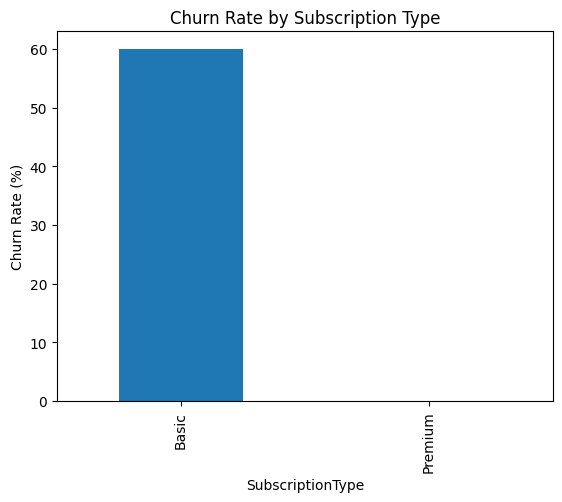

In [7]:
churn_by_sub.plot(kind='bar')
plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.show()


In [8]:
df['CustomerLifetimeDays'] = (df['LastActiveDate'] - df['JoinDate']).dt.days
df[['CustomerID','CustomerLifetimeDays']]


,CustomerID,CustomerLifetimeDays
0,101,365
1,102,303
2,103,328
3,104,127
4,105,240
5,106,75
6,107,224
7,108,50
